# Beyond the Login: Profiling Digital Behavior of Public WiFi Users in Indonesia

This notebook generates synthetic WiFi hotspot login data, performs feature engineering, exploratory data analysis, and calculates 95% confidence intervals for key user metrics.

## 1. Import Required Libraries

In [9]:
import random
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
from faker import Faker
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

SEED = 42
N_ROWS = 500

random.seed(SEED)
np.random.seed(SEED)
fake = Faker("id_ID")
Faker.seed(SEED)

current_year = datetime.now().year

# Dark theme setup for black PPT background
plt.style.use("dark_background")
mpl.rcParams.update({
    "figure.facecolor": "#0D0D0D",
    "axes.facecolor": "#0D0D0D",
    "savefig.facecolor": "#0D0D0D",
    "text.color": "#E0E0E0",
    "axes.labelcolor": "#E0E0E0",
    "xtick.color": "#AAAAAA",
    "ytick.color": "#AAAAAA",
    "axes.edgecolor": "#333333",
    "grid.color": "#222222",
    "grid.alpha": 0.3,
    "font.size": 11,
})

# Color palette: green gradient for bar charts
GREEN_PALETTE = ["#1B5E20", "#2E7D32", "#388E3C", "#43A047", "#4CAF50",
                 "#66BB6A", "#81C784", "#A5D6A7", "#C8E6C9", "#E8F5E9"]
GRAY_PALETTE  = ["#424242", "#616161", "#757575", "#9E9E9E", "#BDBDBD",
                 "#E0E0E0", "#EEEEEE", "#F5F5F5"]
ACCENT_GREEN  = "#66BB6A"

## 2. Generate Dummy Data

In [10]:
lokasi_list = [
    "Jakarta Selatan", "Jakarta Pusat", "Bandung", "Surabaya", "Yogyakarta",
    "Medan", "Makassar", "Semarang", "Denpasar", "Palembang"
]

tipe_lokasi_map = {
    "Jakarta Selatan": "Urban",
    "Jakarta Pusat": "Urban",
    "Bandung": "Urban",
    "Surabaya": "Urban",
    "Yogyakarta": "Tourism",
    "Medan": "Urban",
    "Makassar": "Urban",
    "Semarang": "Urban",
    "Denpasar": "Tourism",
    "Palembang": "Suburban",
}

merk_hp = ["Samsung", "Xiaomi", "OPPO", "Vivo", "Apple", "Realme", "Infinix", "Huawei"]
minat_digital_labels = ["Rendah", "Sedang", "Tinggi", "Sangat Tinggi"]

rows = []
for _ in range(N_ROWS):
    lokasi = random.choice(lokasi_list)
    tahun_lahir = random.randint(1970, 2006)
    hour = int(np.clip(np.random.normal(loc=13, scale=4), 0, 23))
    minute = random.randint(0, 59)
    jam_login = f"{hour:02d}:{minute:02d}"

    nama = fake.name()
    email = fake.email()
    phone = f"08{random.randint(11, 99)}-{random.randint(1000, 9999)}-{random.randint(1000, 9999)}"

    minat = random.choices(minat_digital_labels, weights=[0.15, 0.35, 0.35, 0.15], k=1)[0]
    brand = random.choices(merk_hp, weights=[0.24, 0.20, 0.14, 0.13, 0.12, 0.09, 0.05, 0.03], k=1)[0]

    rows.append(
        {
            "Nama Lokasi": lokasi,
            "Jam Login": jam_login,
            "Nama": nama,
            "Email": email,
            "No Telepon": phone,
            "Tahun Lahir": tahun_lahir,
            "Merk HP": brand,
            "Minat Digital": minat,
            "Tipe Lokasi": tipe_lokasi_map[lokasi],
        }
    )

df = pd.DataFrame(rows)
df.head()

,Nama Lokasi,Jam Login,Nama,Email,No Telepon,Tahun Lahir,Merk HP,Minat Digital,Tipe Lokasi
0,Jakarta Pusat,14:47,"Balidin Dongoran, S.T.",ivanmandala@example.net,0846-5012-4657,1971,Samsung,Rendah,Urban
1,Denpasar,12:37,Murti Palastri,rahayusurya@example.org,0865-1520-1488,1975,Samsung,Rendah,Tourism
2,Palembang,15:35,Bakiman Pratama,corneliasuartini@example.org,0836-9928-7873,1971,Vivo,Sedang,Suburban
3,Jakarta Selatan,19:44,Sutan Nasrullah Yulianti,cprasetya@example.net,0865-6574-5552,1980,Infinix,Sedang,Urban
4,Medan,12:05,Yessi Ardianto,zeldaanggraini@example.com,0859-2584-6881,1976,Vivo,Tinggi,Urban


In [11]:
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}\n")
df.describe(include="all").T

Shape: (500, 9)
Columns: ['Nama Lokasi', 'Jam Login', 'Nama', 'Email', 'No Telepon', 'Tahun Lahir', 'Merk HP', 'Minat Digital', 'Tipe Lokasi']



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Nama Lokasi,500,10,Yogyakarta,65,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Jam Login,500,379,14:41,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nama,500,500,"Balidin Dongoran, S.T.",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Email,500,500,ivanmandala@example.net,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
No Telepon,500,500,0846-5012-4657,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tahun Lahir,500.0,NaN,NaN,NaN,1988.252,10.471667,1970.0,1979.0,1988.0,1997.0,2006.0
Merk HP,500,8,Samsung,113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Minat Digital,500,4,Sedang,194,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tipe Lokasi,500,3,Urban,335,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Feature Engineering (Derived Variables)

In [12]:
def map_generasi(tahun):
    if tahun >= 1997:
        return "Gen Z"
    if tahun >= 1981:
        return "Millennial"
    if tahun >= 1965:
        return "Gen X"
    return "Boomer"


def map_waktu_sesi(jam):
    h = int(jam.split(":")[0])
    if 5 <= h < 11:
        return "Pagi"
    if 11 <= h < 16:
        return "Siang"
    if 16 <= h < 20:
        return "Sore"
    return "Malam"


def map_status_aktif(h):
    # Jam aktif puncak diasumsikan berada pada jam makan siang dan malam awal.
    return "Aktif" if h in {11, 12, 13, 19, 20, 21} else "Kurang Aktif"

minat_to_skor = {
    "Rendah": 25,
    "Sedang": 50,
    "Tinggi": 75,
    "Sangat Tinggi": 95,
}

df["Usia"] = current_year - df["Tahun Lahir"]
df["Generasi"] = df["Tahun Lahir"].apply(map_generasi)
df["Jam Login Int"] = df["Jam Login"].str.slice(0, 2).astype(int)
df["Waktu Sesi"] = df["Jam Login"].apply(map_waktu_sesi)
df["Skor Minat Digital"] = df["Minat Digital"].map(minat_to_skor)
df["Status Aktif"] = df["Jam Login Int"].apply(map_status_aktif)
df["Domain Email"] = df["Email"].str.split("@").str[-1]

df.head()

,Nama Lokasi,Jam Login,Nama,Email,No Telepon,Tahun Lahir,Merk HP,Minat Digital,Tipe Lokasi,Usia,Generasi,Jam Login Int,Waktu Sesi,Skor Minat Digital,Status Aktif,Domain Email
0,Jakarta Pusat,14:47,"Balidin Dongoran, S.T.",ivanmandala@example.net,0846-5012-4657,1971,Samsung,Rendah,Urban,55,Gen X,14,Siang,25,Kurang Aktif,example.net
1,Denpasar,12:37,Murti Palastri,rahayusurya@example.org,0865-1520-1488,1975,Samsung,Rendah,Tourism,51,Gen X,12,Siang,25,Aktif,example.org
2,Palembang,15:35,Bakiman Pratama,corneliasuartini@example.org,0836-9928-7873,1971,Vivo,Sedang,Suburban,55,Gen X,15,Siang,50,Kurang Aktif,example.org
3,Jakarta Selatan,19:44,Sutan Nasrullah Yulianti,cprasetya@example.net,0865-6574-5552,1980,Infinix,Sedang,Urban,46,Gen X,19,Sore,50,Aktif,example.net
4,Medan,12:05,Yessi Ardianto,zeldaanggraini@example.com,0859-2584-6881,1976,Vivo,Tinggi,Urban,50,Gen X,12,Siang,75,Aktif,example.com


## 4. Exploratory Data Analysis (EDA)

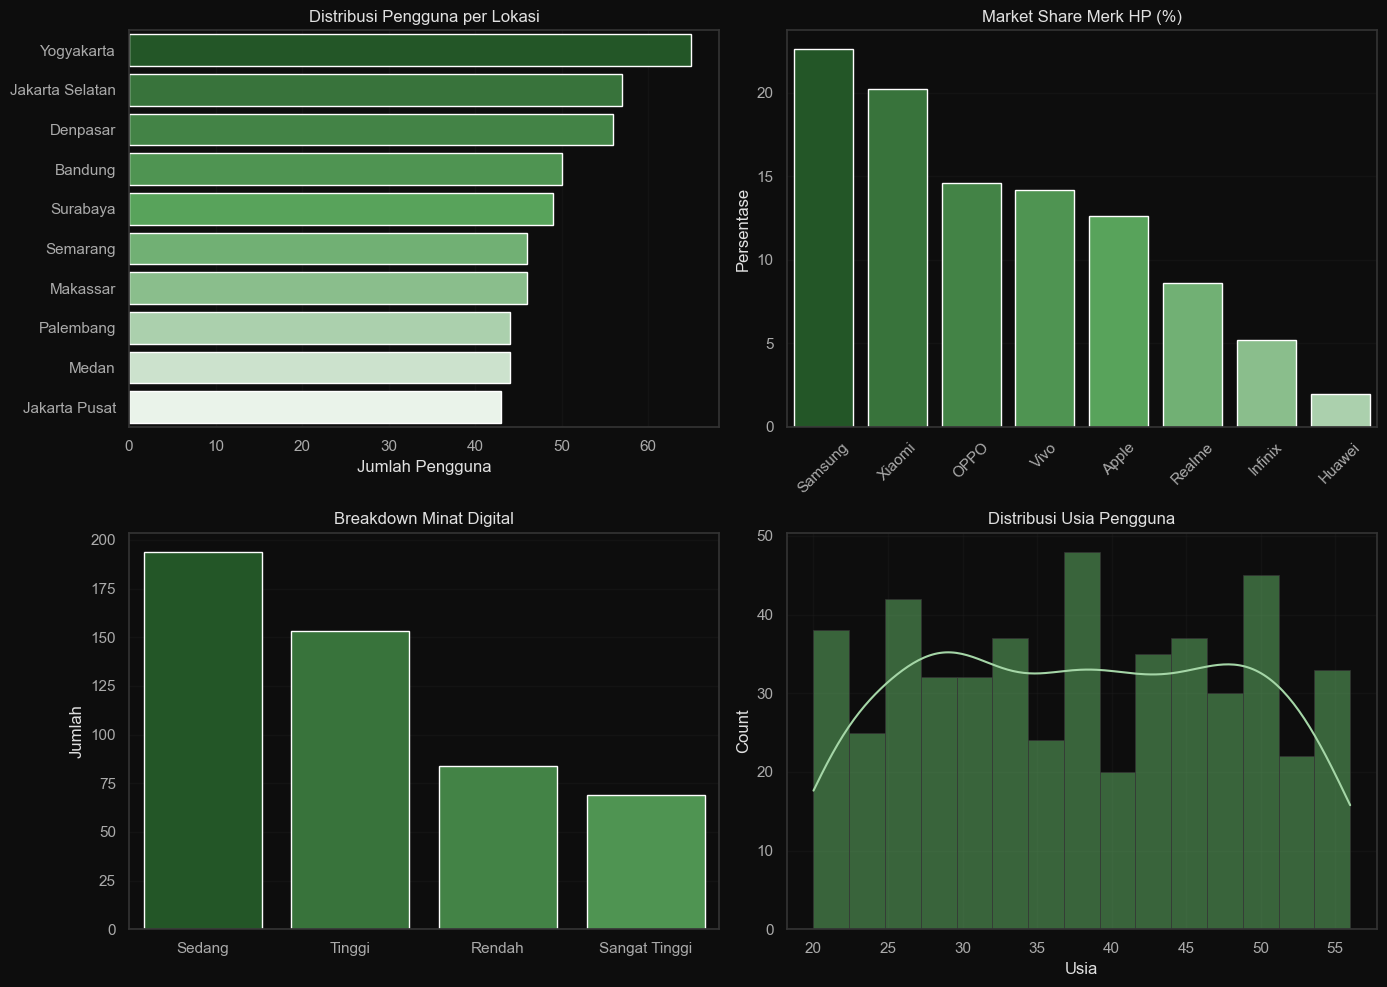

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1 - Distribusi pengguna per lokasi
loc_counts = df["Nama Lokasi"].value_counts().reset_index()
loc_counts.columns = ["Lokasi", "Jumlah"]
sns.barplot(data=loc_counts, x="Jumlah", y="Lokasi", hue="Lokasi",
            palette=GREEN_PALETTE[:len(loc_counts)], legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Distribusi Pengguna per Lokasi", color="#E0E0E0")
axes[0, 0].set_xlabel("Jumlah Pengguna")
axes[0, 0].set_ylabel("")

# 2 - Market share merk HP
brand_counts = df["Merk HP"].value_counts(normalize=True).mul(100).round(1).reset_index()
brand_counts.columns = ["Merk", "Persen"]
sns.barplot(data=brand_counts, x="Merk", y="Persen", hue="Merk",
            palette=GREEN_PALETTE[:len(brand_counts)], legend=False, ax=axes[0, 1])
axes[0, 1].set_title("Market Share Merk HP (%)", color="#E0E0E0")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Persentase")
axes[0, 1].tick_params(axis="x", rotation=45)

# 3 - Breakdown minat digital
interest_counts = df["Minat Digital"].value_counts().reset_index()
interest_counts.columns = ["Kategori", "Jumlah"]
sns.barplot(data=interest_counts, x="Kategori", y="Jumlah", hue="Kategori",
            palette=GREEN_PALETTE[:len(interest_counts)], legend=False, ax=axes[1, 0])
axes[1, 0].set_title("Breakdown Minat Digital", color="#E0E0E0")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Jumlah")

# 4 - Histogram usia
sns.histplot(df["Usia"], bins=15, kde=True, ax=axes[1, 1],
             color=ACCENT_GREEN, edgecolor="#333333", linewidth=0.5)
axes[1, 1].lines[0].set_color("#A5D6A7")
axes[1, 1].set_title("Distribusi Usia Pengguna", color="#E0E0E0")
axes[1, 1].set_xlabel("Usia")

plt.tight_layout()
plt.show()

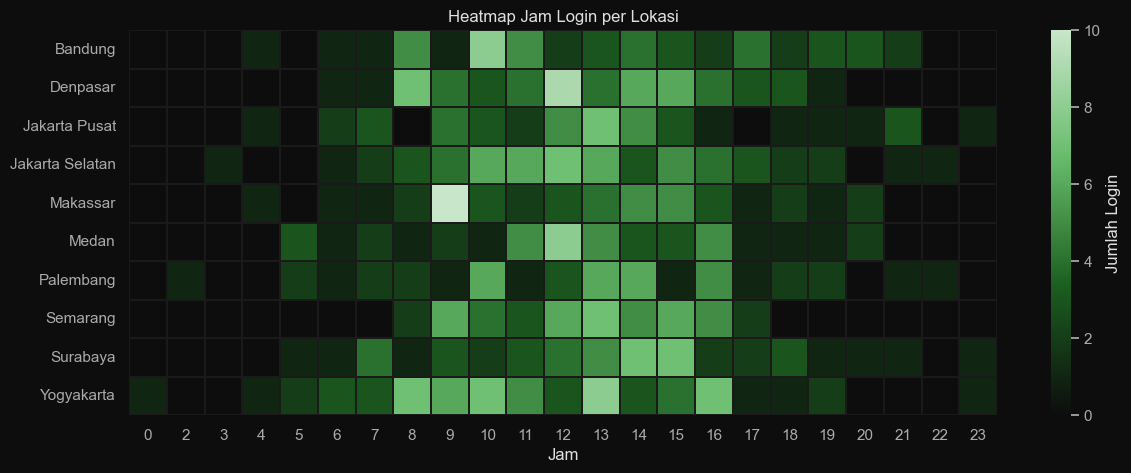

In [14]:
# Heatmap login hour vs location
heatmap_df = (
    df.groupby(["Nama Lokasi", "Jam Login Int"]).size().reset_index(name="Jumlah")
    .pivot(index="Nama Lokasi", columns="Jam Login Int", values="Jumlah")
    .fillna(0)
)

from matplotlib.colors import LinearSegmentedColormap
green_cmap = LinearSegmentedColormap.from_list("dark_green", ["#0D0D0D", "#1B5E20", "#66BB6A", "#C8E6C9"])

plt.figure(figsize=(14, 5))
sns.heatmap(heatmap_df, cmap=green_cmap, linewidths=0.3, linecolor="#1A1A1A",
            cbar_kws={"label": "Jumlah Login"})
plt.title("Heatmap Jam Login per Lokasi", color="#E0E0E0")
plt.xlabel("Jam")
plt.ylabel("")
plt.show()

## 5. Confidence Interval Calculation

Formula CI 95%:

\[
\bar{x} \pm t_{\alpha/2,\,n-1} \cdot \frac{s}{\sqrt{n}}
\]

In [15]:
def mean_ci_t(series, confidence=0.95):
    data = pd.Series(series).dropna()
    n = len(data)
    mean_val = data.mean()
    std_val = data.std(ddof=1)
    se = std_val / np.sqrt(n)
    alpha = 1 - confidence
    t_crit = stats.t.ppf(1 - alpha / 2, df=n - 1)
    margin = t_crit * se
    return mean_val, mean_val - margin, mean_val + margin

usia_mean, usia_low, usia_high = mean_ci_t(df["Usia"], confidence=0.95)
skor_mean, skor_low, skor_high = mean_ci_t(df["Skor Minat Digital"], confidence=0.95)

ci_summary = pd.DataFrame(
    {
        "Metrik": ["Rata-rata Usia", "Rata-rata Skor Minat Digital"],
        "Mean": [usia_mean, skor_mean],
        "CI Lower 95%": [usia_low, skor_low],
        "CI Upper 95%": [usia_high, skor_high],
    }
)

ci_summary

,Metrik,Mean,CI Lower 95%,CI Upper 95%
0,Rata-rata Usia,37.748,36.827903,38.668097
1,Rata-rata Skor Minat Digital,59.660,57.728258,61.591742


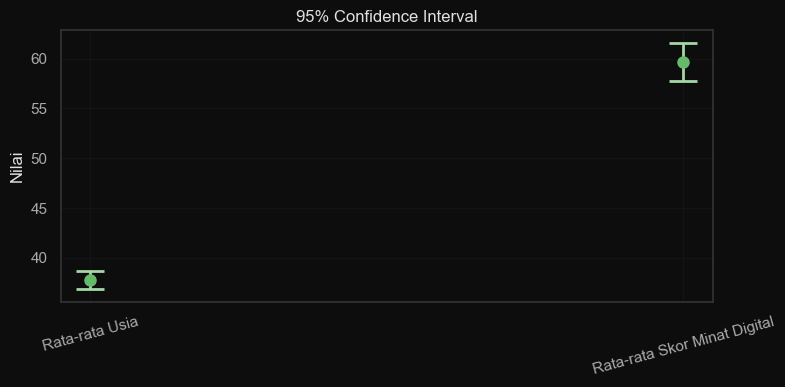

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
means = ci_summary["Mean"].values
errors_lower = means - ci_summary["CI Lower 95%"].values
errors_upper = ci_summary["CI Upper 95%"].values - means

ax.errorbar(
    x=ci_summary["Metrik"],
    y=means,
    yerr=[errors_lower, errors_upper],
    fmt="o",
    capsize=10,
    color=ACCENT_GREEN,
    ecolor="#A5D6A7",
    elinewidth=2,
    capthick=2,
    markersize=8,
)
ax.set_title("95% Confidence Interval", color="#E0E0E0")
ax.set_ylabel("Nilai")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

## 6. Export Data to CSV

In [17]:
output_dir = Path("data")
output_dir.mkdir(parents=True, exist_ok=True)

final_df = df.drop(columns=["Jam Login Int"])
final_df.to_csv(output_dir / "dummy_data_digital_users.csv", index=False)
ci_summary.to_csv(output_dir / "ci_summary.csv", index=False)

print("File tersimpan:")
print(output_dir / "dummy_data_digital_users.csv")
print(output_dir / "ci_summary.csv")

final_df.head()

File tersimpan:
data\dummy_data_digital_users.csv
data\ci_summary.csv


,Nama Lokasi,Jam Login,Nama,Email,No Telepon,Tahun Lahir,Merk HP,Minat Digital,Tipe Lokasi,Usia,Generasi,Waktu Sesi,Skor Minat Digital,Status Aktif,Domain Email
0,Jakarta Pusat,14:47,"Balidin Dongoran, S.T.",ivanmandala@example.net,0846-5012-4657,1971,Samsung,Rendah,Urban,55,Gen X,Siang,25,Kurang Aktif,example.net
1,Denpasar,12:37,Murti Palastri,rahayusurya@example.org,0865-1520-1488,1975,Samsung,Rendah,Tourism,51,Gen X,Siang,25,Aktif,example.org
2,Palembang,15:35,Bakiman Pratama,corneliasuartini@example.org,0836-9928-7873,1971,Vivo,Sedang,Suburban,55,Gen X,Siang,50,Kurang Aktif,example.org
3,Jakarta Selatan,19:44,Sutan Nasrullah Yulianti,cprasetya@example.net,0865-6574-5552,1980,Infinix,Sedang,Urban,46,Gen X,Sore,50,Aktif,example.net
4,Medan,12:05,Yessi Ardianto,zeldaanggraini@example.com,0859-2584-6881,1976,Vivo,Tinggi,Urban,50,Gen X,Siang,75,Aktif,example.com
